In [150]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [151]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass
     

In [152]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost
     


In [153]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])
     


In [154]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state==self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []
        for key in MOVES:
            values=MOVES[key]
            n_cell = (state[0]+values[0],state[1]+values[1])
            row,col=state[0]+values[0],state[1]+values[1]
            if (n_cell[0] > -1 and n_cell[1] >-1) and (n_cell[0]<len(self.grid) and n_cell[1]<len(self.grid[0]) ):# makes sure its not a negative number or outside bounds
                if self.grid[row][col] == 0:
                    legal_actions.append(key)
        
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state  # assigns current coordinates to the row and col variables
        dr, dc = MOVES[action]  # assigns action movement to the variables
        return (row + dr, col + dc)
        

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s= node.state
        nodes=[]
        for action in problem.actions(s):
            s_prime=problem.result(s,action)
            cost=node.path_cost + problem.action_cost(s, action, s_prime)
            nodes.append(Node(state=s_prime, parent=node, action=action, path_cost=cost))
        return nodes
        

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass
     

In [155]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
     

In [156]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        row,col=next_state
        return self.terrain_costs[row][col]
        # 2. Return self.terrain_costs[row][col].
        

In [157]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [158]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    r1, c1=state
    r2,c2=goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1-r2)+abs(c1-c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    r1, c1=state
    r2,c2=goal
    return math.sqrt(((r1-r2)**2)+((c1-c2)**2))
    # Hint: math.sqrt(...) or math.dist(state, goal).
   


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [159]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [160]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [161]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node=Node(state=problem.initial_state())
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        frontier=PriorityQueue()
        frontier.push(self.evaluation(node=node,problem=problem),node=node)
        reached={problem.initial_state():node}
        nodes_expanded = 0
        max_frontier_size = 1
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        while frontier:
            node=frontier.pop()
            if problem.is_goal(node.state):
                return SearchResult(algorithm=self.algorithm_name,solution=node,status="success",max_frontier_size=max_frontier_size,nodes_expanded=nodes_expanded, reached_count=len(reached))
            nodes_expanded+=1
            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or (child.path_cost < reached[s].path_cost):
                    reached[s] = child
                    frontier.push(self.evaluation(node=child,problem=problem),child)
            max_frontier_size=len(frontier)
        return SearchResult(algorithm=self.algorithm_name,solution=None,status="failure",max_frontier_size=max_frontier_size,nodes_expanded=nodes_expanded, reached_count=len(reached))
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        

In [162]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        return self.h(node=node,problem=problem)#returns heuristic
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        
     

In [163]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node=node,problem=problem)
     

In [164]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost# returns g(n)

In [165]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost+(self.weight*self.h(node=node,problem=problem))

In [166]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [167]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18.0,52,4,56
1,A*,success,18,18.0,18,5,23
2,Weighted A* (W=2),success,18,18.0,18,5,23
3,Greedy,success,18,18.0,18,5,23


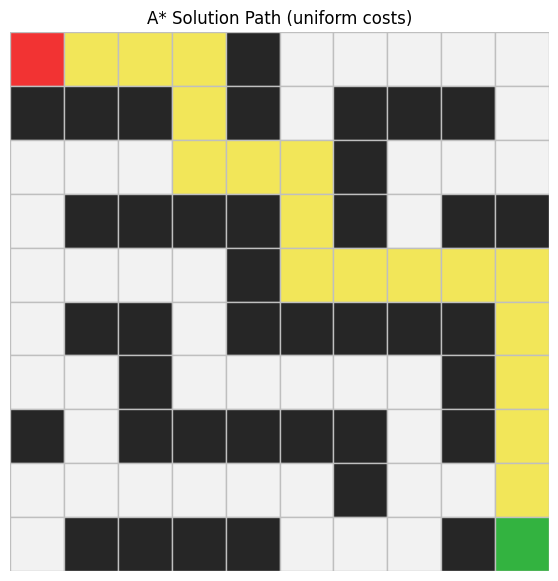

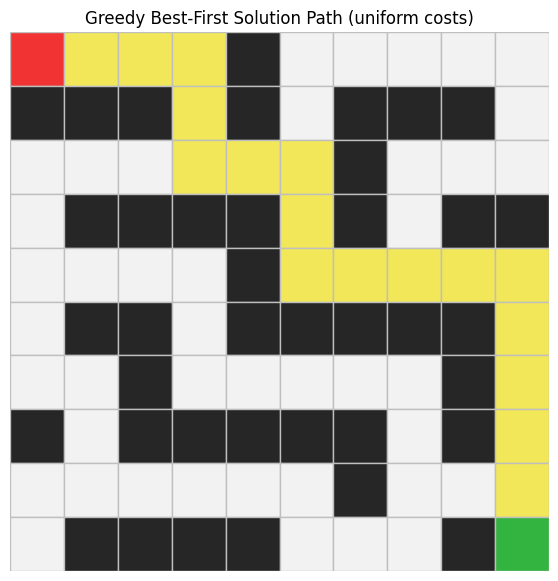

In [168]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [169]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,9,35
1,A*,success,10,10,25,9,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


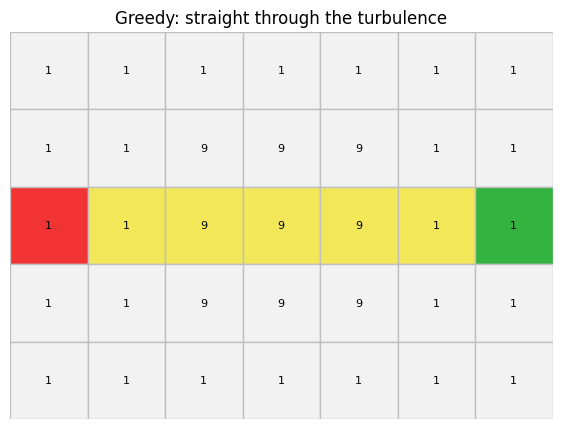

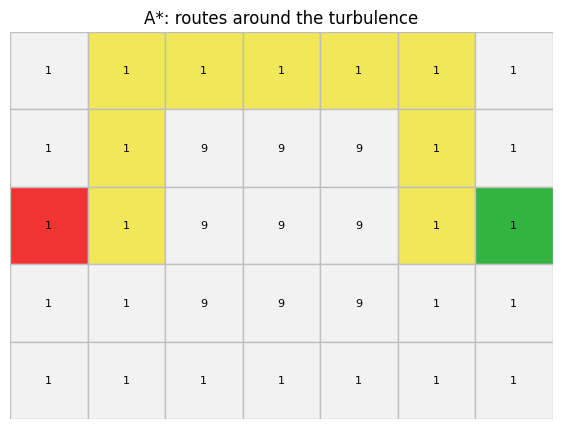

In [170]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [171]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    def h(state, goal):
        return factor*manhattan_distance(state=state,goal=goal)
    return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,6,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


1. the mild turbulence had a sub optimal path by 2
2. it expanded 6, which is 23 less than what the admissible 
3. Yes I would when i need to quickly find a solution which can work but it doesnt have to be perfect. 

In [196]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def f_limited_search(self, node:Node, limit:int, problem:Problem)-> Tuple[Node,float]:
            
            f=node.path_cost+self.heuristic(node.state,problem.goal)
            if f> limit:
                return None, f
            if problem.is_goal(node.state):
                return node,f
            next_limit=math.inf
            for child in self.expand(problem=problem, node=node):
                if child.state == node.parent and child.state== node.state:
                    continue
                result, new_f=self.f_limited_search(child,limit=limit,problem=problem)
                if problem.is_goal(result):
                    return result,new_f
                next_limit=min(next_limit,new_f)
            return None, next_limit
    


    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
        nodes_expanded=0
        limit =self.heuristic(problem.initial_state(),problem.goal)
        max_frontier_size=0
        SearchResult.iterations=[[limit,0]]
        while True:
            nodes_expanded+=1
            max_frontier_size+=1
            result, next_limit=self.f_limited_search(Node(state=problem.initial_state()),limit=limit,problem=problem)
            SearchResult.iterations.append([limit,result])
            if problem.is_goal(result):
                return SearchResult(algorithm=self.algorithm_name,solution=result,status="success",max_frontier_size=max_frontier_size)
            if next_limit==math.inf:
                return SearchResult(algorithm=self.algorithm_name,solution=None,status="failure",max_frontier_size=max_frontier_size)
            limit= next_limit
            if max_frontier_size==max_iterations-1:
                return SearchResult(algorithm=self.algorithm_name,solution=None,status="cutoff",max_frontier_size=max_frontier_size,nodes_expanded=nodes_expanded)
        



# After completing the bonus, compare IDA* with A* here:
ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18.0,18.0,18,5,23
1,IDA*,cutoff,NaN,NaN,199,199,0


In [181]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0]
    # Replace this with your own grid.
]

custom_costs_1 = [
    [1, 1, 2, 2, 1, 1, 4],
    [1, 3, 2, 1, 1, 1, 1],
    [1, 1, 2, 2, 2, 1, 1],
    [3, 3, 2, 2, 3, 2, 1],
    [3, 1, 3, 3, 1, 1, 1],
    [1, 3, 1, 1, 3, 1, 2]
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
]

custom_start_1 = (2,0)
custom_goal_1 = (4,6)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
 )
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,8,11,37,4,41
1,A*,success,8,11,14,14,28
2,Weighted A* (W=2),success,8,11,10,14,24
3,Greedy,success,8,16,8,14,22


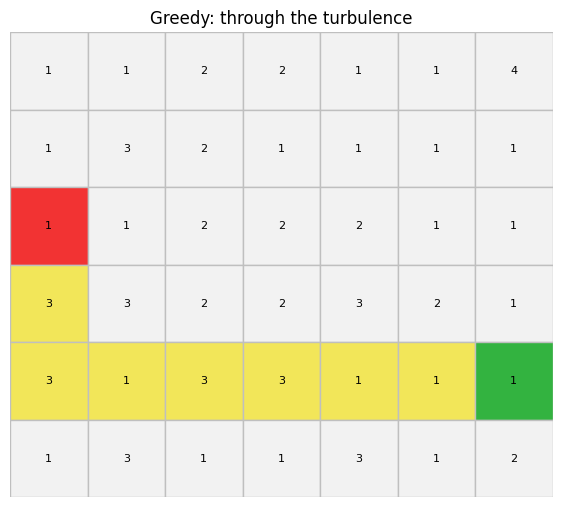

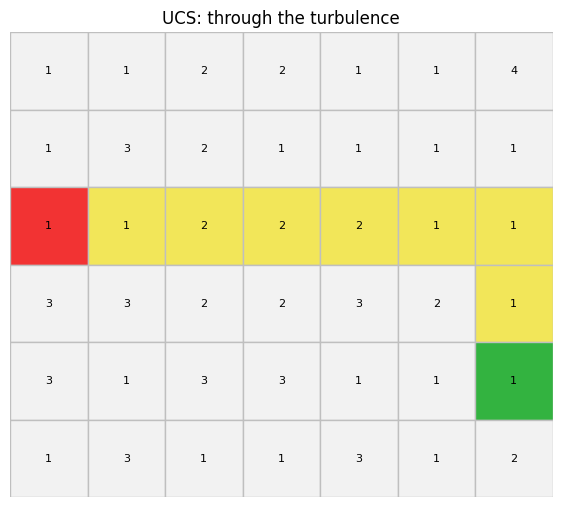

In [183]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    terrain_costs=custom_costs_1,
    title="Greedy: through the turbulence",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    terrain_costs=custom_costs_1,
    title="UCS: through the turbulence",
)

In [179]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    # Replace this with your own grid.
]

custom_costs_2 = [
    [1, 1, 2, 4, 1, 1, 1, 3, 2, 1, 1, 1, 8],
    [1, 1, 2, 2, 1, 2, 4, 3, 2, 1, 1, 1, 1],
    [1, 1, 1, 2, 1, 1, 1, 5, 2, 4, 1, 1, 1],
    [1, 1, 2, 1, 1, 1, 4, 3, 2, 1, 8, 1, 1],
    [1, 1, 2, 2, 1, 1, 2, 3, 2, 1, 1, 9, 1]
    
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
]

custom_start_2 = (0,2)
custom_goal_2 = (4,11)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,13,27,64,1,65
1,A*,success,13,27,70,3,65
2,Weighted A* (W=2),success,13,27,34,19,43
3,Greedy,success,13,29,13,17,30


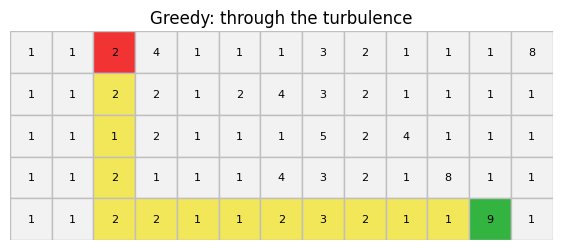

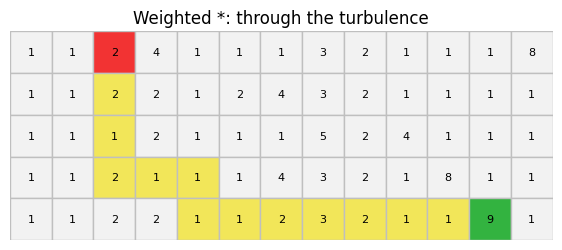

In [180]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy: through the turbulence",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="Weighted *: through the turbulence",
)

16.1 Heuristic Functions
1. h(n) estimates the cost of moving from a state to a goal, its knowledge comes from the straight line distance between the goal and the state and the number of moves it would need to get to the goal if there were no obstacles. It uses the grid positions as its arguments.
2. It removes the idea that there would be obstacles, which is the restricytion the origional problem had.
3. The manhattan distance dominates the euclidean distance, this means that nodes expanded would be more likely to be better paths as bad paths are elimnated quicker
4.  1 can be treated as the base cost which is the normal, so is standardized across all nodes and anything higher is seen as more difficult than normal, if it is less tyhen there is no baseline to start from. A terrain of 0.5 might lead to the model getting confused which might lead to loops

16.2 Greedy Best-First Search
1. It ignores the path cost and any possible weights. This means that in a turbulence it chooses the fastest possible method ignoring any heavy weights in the middle, this means that in real lif e it would cost more
2.This is because it doesnt prioritze optimality just speed, the A* does which means it might cost less to get to a point.
3. If it had to deliver a heart or a body part for an urgent surgery, it might need to ignore any weights or costs incurred

16.3 A* Search
1. It choses the node with the lowest estimated total cost from the node to the goal
2. If it is tested when generated then the model might end up testing an unecessary amount nodes, if tested earlier the A* might take a less optimal route which is more expensive
3.
4. Ucs expanded 1 more node than A* the heuristic must be very small as there is little difference

16.4 Admissibility and Consistency
1. Admissible means that the heuristic must be an underestimatee of the true cost to reach a goal, consistent means that the h() for a child node must the less than the cumulative heuristic of all its parent nodes
2. On a uniform map there was almost no difference between the inadmissible and admissible, but with the mild turbulence the inadmissible expanded fewer nodes to get to the goal, it. is more optimal to use inadmissible heuristics to compute for the best path especially with turbulence
3. the h(n) of (0, 0) is 4 and the h(n) of (0, 1) is 3 and the h(n) of (0,1) is less than that of h(n) of (0,0). Which leans into the idea that the actions are moving nearer to the goal.

16.5 Weighted A* and Trade-offs
1. The weight is 0 for the UCS, it is infinity for the Greedy Best First and 1 for A*
2. It means that the cost will stay within a pre specified range which is between the optimal cost and W x C*, the weight was 2 and its cost was 28, the optimal cost was 28 as well was in the range
3. I would use weighted A* with a weight of 2 as we need to compute a route as fast as possible which is very optimal as well

16.6 Memory and Real-World Drone Context
1. It becomes memory hungry when the grid is large and each node has a lot of child nodes. The IDA* uses linear space as it only stores nodes in the f-cost limit, it pays by having to revisit states multiple times
2. Weather, the terrain, whether birds are known to frequent that location, human concentration
3. the heuristic is ever changing so it is difficult to estimate the best path, it can use heuristics used in similar environments
4. I would use the IDA* as it combines the optimality of the A* search with memory saving which is very helpful as the drone might have limited storage space but would need an optimal path.